# Store Sales - Time Series Forecasting

Kaggle competition (https://www.kaggle.com/competitions/store-sales-time-series-forecasting/data) predicting sales for Favorita stores in Ecuador.

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

# set matplotlib defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc("axes",
       labelweight="bold", labelsize="large",
       titleweight="bold", titlesize=14, titlepad=10)
plot_params = dict(color="0.75", style=".-",
                   markeredgecolor="0.25", markerfacecolor="0.25",
                   legend=False)
%config InlineBackend.figure_format = 'retina'

dtype = {'store_nbr': 'category',
         'family': 'category',
         'sales': 'float32',
         'onpromotion': 'uint64'}

# load training data
store_sales = pd.read_csv('data/train.csv', dtype=dtype, parse_dates=['date'])
store_sales.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [63]:
# set index to Period Index
store_sales = store_sales.set_index('date').to_period('D')
store_sales.head()

,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0


In [64]:
# create sub-indices based on store and product family
store_sales = store_sales.set_index(['store_nbr', 'family'], append=True)
store_sales.head()

id  sales  onpromotion
date       store_nbr family                            
2013-01-01 1         AUTOMOTIVE   0    0.0            0
                     BABY CARE    1    0.0            0
                     BEAUTY       2    0.0            0
                     BEVERAGES    3    0.0            0
                     BOOKS        4    0.0            0

In [65]:
# find the average sales for a given date across all stores
average_sales = store_sales.groupby('date').mean()['sales']

## Create linear regression model with a time-step feature

Text(0.5, 1.0, 'Time Plot of Total Store Sales')

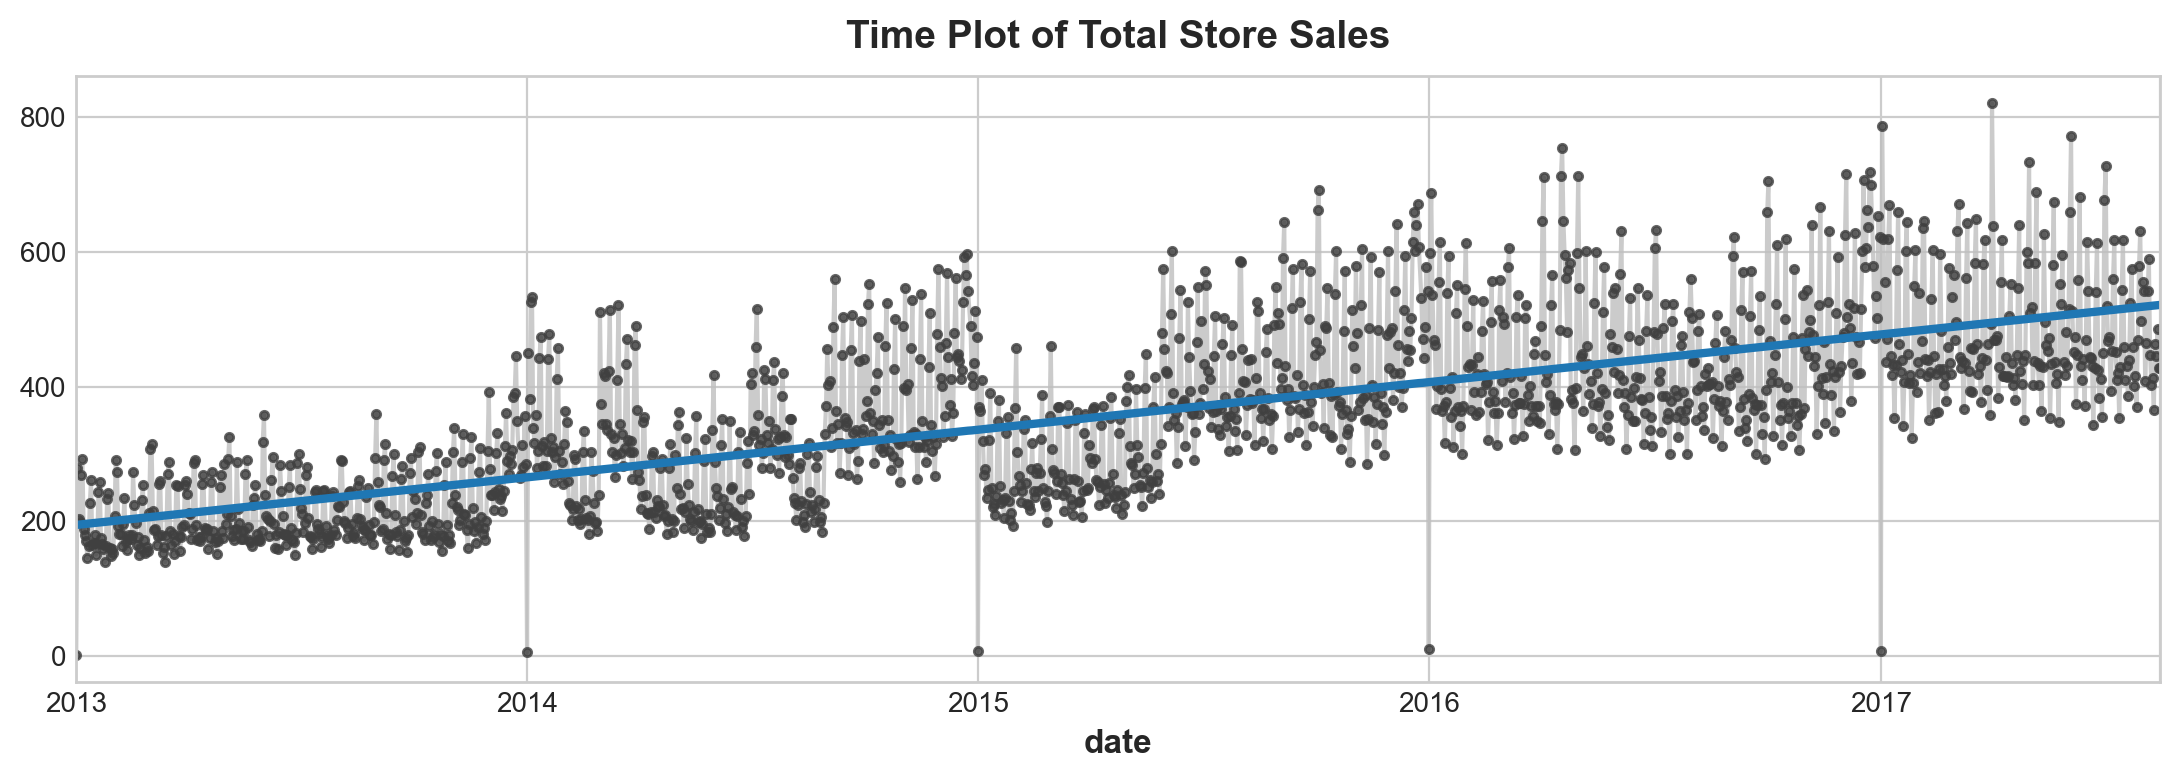

In [68]:
from sklearn.linear_model import LinearRegression

df = average_sales.to_frame()

# create a time dummy
time = np.arange(len(df.index))
df['time'] = time

# organize training data
X = df.loc[:, ['time']] # features; type = DataFrame
y = df.loc[:, 'sales'] # target; type = Series

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

# plot store sales
ax = y.plot(**plot_params, alpha=0.8)
ax = y_pred.plot(ax=ax, linewidth=3)
ax.set_title('Time Plot of Total Store Sales')

## Create linear regression model with a lag feature

In [69]:
# create 1-day shift lag feature & add to dataframe
lag_1 = df['sales'].shift(1)
df['lag_1'] = lag_1

X = df.loc[:, ['lag_1']].dropna() # features; drop null
y = df.loc[:, 'sales'] # target
y, X = y.align(X, join='inner') # drop the corresponding values in target (works since they have the same indexing)

# train linear regression model
model = LinearRegression()
model.fit(X, y)

# index predicted values with the same time index as training data
y_pred = pd.Series(model.predict(X), index=X.index)

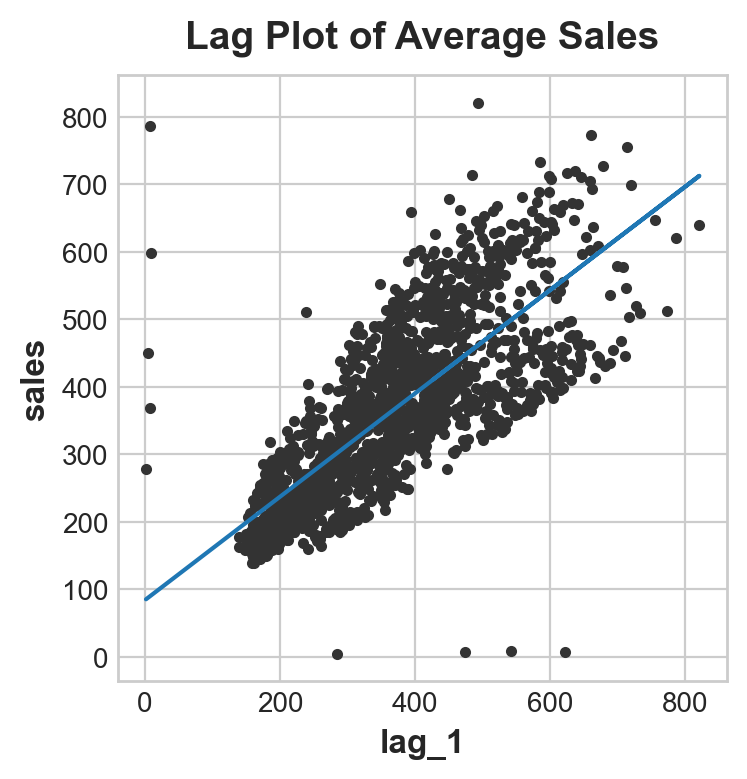

In [74]:
fig, ax = plt.subplots()
ax.plot(X['lag_1'], y, '.', color='0.2')
ax.plot(X['lag_1'], y_pred)
ax.set(aspect='equal', ylabel='sales', xlabel='lag_1', title='Lag Plot of Average Sales');